# Conversational AI Assignment
**Course:** Conversational AI (M.Tech)
**Assignment:** Conversational AI - Project Assignment

## Student Details
- Name:
- Roll Number / ID:
- Department:
- Email:
- Group Members (if group assignment) and Contribution Areas:
  - Member 1: (contribution)
  - Member 2: (contribution)

## Problem Statement
Build and evaluate a semantic retrieval and FAQ matching system that demonstrates the complete retrieval pipeline:
- User Query → BM25 Keyword Retrieval → Dense Vector Retrieval → Hybrid Ranking (RRF) → Cross-Encoder Re-ranking → Match Decision

The system should leverage the concepts covered in the course:
- BPE Tokenization — implement from scratch
- Transformer Encoder — implement from scratch (Session 2, pages 6-8, 21)
- Contextual Embeddings — derive from encoder models (Session 2 + DistilBERT notebook)
- Vector Similarity — cosine, dot product, L2 distance (Similarity notebook)
- ANN Search — HNSW, IVF, PQ concepts (Session 2-3)
- BM25 Sparse Retrieval — built on TF–IDF foundations (Session 3)
- Hybrid Search with RRF — combine sparse and dense signals (Session 3 + Similarity notebook)
- Cross-Encoder Re-ranking — final fine-grained scoring using a pre-trained cross-encoder model (Similarity notebook)

The goal is to produce a reproducible pipeline that: (1) retrieves candidate passages using both sparse and dense methods, (2) fuses rankings via RRF, (3) re-ranks with a cross-encoder for high-precision matches, and (4) outputs a final match decision and evaluation metrics for FAQ matching scenarios.

## Dataset Details and Source
- Dataset name: Quora Question Pairs (SentenceTransformers / quora-duplicates)
- Source / URL: https://huggingface.co/datasets/sentence-transformers/quora-duplicates
- Size / number of examples: The Quora duplicate-question dataset contains question pairs labeled as duplicate or non-duplicate; typical usage includes training and evaluation splits across thousands of pairs. For this assignment, the dataset is used for BPE tokenizer training and downstream duplicate detection experiments.
- Format: Parquet / Hugging Face Dataset (question pairs with labels and optional metadata)
- Licensing and usage notes: Publicly available dataset on Hugging Face; used for academic/educational experimentation in this assignment. The data is used for research and learning purposes, and the implementation reports and evaluates the tokenizer and retrieval pipeline on this dataset.
- Task relevance: This dataset is used for Task 1: Byte Pair Encoding Tokenizer with Optimization Analysis, where the tokenizer is trained from scratch on question text and evaluated using duplicate detection and tokenization metrics.

## Tools and Libraries Used
- Python 3.10+
- Jupyter Notebook / VS Code
- NumPy for numerical arrays and token statistics
- Pandas for dataset handling and tabular processing
- Matplotlib and Seaborn for visualizations
- Hugging Face Datasets for loading the Quora question-pair dataset
- PyTorch for implementing the custom transformer encoder and training pipeline
- Transformers library for pretrained encoder models and cross-encoder re-ranking
- scikit-learn for token statistics, evaluation metrics, and similarity analysis
- rank-bm25 for BM25 sparse retrieval
- faiss or ANN libraries for dense retrieval experimentation (HNSW / IVF / PQ)
- sentence-transformers for contextual embedding generation using DistilBERT, MiniLM, and BGE/GTE models
- Standard Python libraries: os, re, collections, math, random
- Notebooks and experimentation workflow: VS Code + Jupyter kernel
- Task-specific focus: BPE tokenizer implementation from scratch, custom transformer encoder, embeddings, sparse/dense retrieval, hybrid ranking, and cross-encoder re-ranking

## Module 1: Task 1 — Custom BPE Tokenizer (from scratch)



In [1]:
%pip install -q numpy pandas datasets matplotlib


In [1]:
import os
import re
import time
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from datasets import load_dataset

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

SPECIAL_TOKENS = {"[PAD]": 0, "[UNK]": 1, "[CLS]": 2, "[SEP]": 3}


class BPETokenizer:
    def __init__(self, vocab_size=5000, special_tokens=None):
        self.vocab_size = vocab_size
        self.special_tokens = special_tokens if special_tokens is not None else SPECIAL_TOKENS.copy()
        self.token_to_id = self.special_tokens.copy()
        self.id_to_token = {v: k for k, v in self.token_to_id.items()}
        self.merges = []
        self.merge_counts = Counter()

    def _normalize_text(self, text):
        text = str(text).lower()
        text = re.sub(r"[^a-z0-9\s']+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def get_word_frequencies(self, corpus):
        freq = Counter()
        for sentence in corpus:
            normalized = self._normalize_text(sentence)
            if not normalized:
                continue
            for token in normalized.split():
                freq[token] += 1
        return freq

    def fit(self, corpus, vocab_size=None):
        if vocab_size is not None:
            self.vocab_size = vocab_size

        self.token_to_id = self.special_tokens.copy()
        self.id_to_token = {v: k for k, v in self.token_to_id.items()}
        self.merges = []
        self.merge_rank = {}
        self.merge_counts = Counter()

        word_freq = self.get_word_frequencies(corpus)
        if not word_freq:
            raise ValueError("The training corpus is empty.")

        # Pre-split each word into symbols once
        vocab_symbols = {word: list(word) for word in word_freq}

        # Build initial pair counts and an inverted index in one pass
        pair_counts = defaultdict(int)
        pair_word_index = defaultdict(set)
        for word, symbols in vocab_symbols.items():
            count = word_freq[word]
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i + 1])
                pair_counts[pair] += count
                pair_word_index[pair].add(word)

        while len(self.token_to_id) < self.vocab_size:
            if not pair_counts:
                break

            best_pair = max(pair_counts, key=lambda p: pair_counts[p])
            best_count = pair_counts[best_pair]
            if best_count < 1:
                break

            merged_token = best_pair[0] + best_pair[1]
            self.merge_rank[best_pair] = len(self.merges)
            self.merges.append(best_pair)
            self.merge_counts[best_pair] = best_count
            self.token_to_id[merged_token] = len(self.token_to_id)
            self.id_to_token[len(self.id_to_token)] = merged_token

            # Only re-process words that contain best_pair
            for word in list(pair_word_index.get(best_pair, [])):
                symbols = vocab_symbols[word]
                count = word_freq[word]
                # Remove old pair contributions
                for i in range(len(symbols) - 1):
                    p = (symbols[i], symbols[i + 1])
                    pair_counts[p] -= count
                    pair_word_index[p].discard(word)
                # Apply merge
                new_symbols = []
                i = 0
                while i < len(symbols):
                    if i < len(symbols) - 1 and symbols[i] == best_pair[0] and symbols[i + 1] == best_pair[1]:
                        new_symbols.append(merged_token)
                        i += 2
                    else:
                        new_symbols.append(symbols[i])
                        i += 1
                vocab_symbols[word] = new_symbols
                # Add new pair contributions
                for i in range(len(new_symbols) - 1):
                    p = (new_symbols[i], new_symbols[i + 1])
                    pair_counts[p] += count
                    pair_word_index[p].add(word)

            del pair_counts[best_pair]
            pair_word_index.pop(best_pair, None)

        self.vocab = list(self.token_to_id.keys())
        return self
    def _apply_bpe_to_word(self, word):
        tokens = list(word)
        # O(1) rank lookup via dict instead of list.index()
        merge_rank = getattr(self, 'merge_rank', {p: i for i, p in enumerate(self.merges)})
        while True:
            best_pair = None
            best_rank = None
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                rank = merge_rank.get(pair)
                if rank is not None and (best_rank is None or rank < best_rank):
                    best_rank = rank
                    best_pair = pair
            if best_pair is None:
                break
            merged = best_pair[0] + best_pair[1]
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens) - 1 and (tokens[i], tokens[i + 1]) == best_pair:
                    new_tokens.append(merged)
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            tokens = new_tokens
        return tokens
    def encode(self, sentence, add_special_tokens=True):
        normalized = self._normalize_text(sentence)
        if not normalized:
            tokens = []
        else:
            tokens = []
            for word in normalized.split():
                tokens.extend(self._apply_bpe_to_word(word))
        if add_special_tokens:
            tokens = ["[CLS]"] + tokens + ["[SEP]"]
        token_ids = [self.token_to_id.get(tok, self.token_to_id["[UNK]"]) for tok in tokens]
        return tokens, token_ids

    def encode_batch(self, texts, add_special_tokens=True):
        return [self.encode(text, add_special_tokens=add_special_tokens) for text in texts]

    def get_top_merges(self, n=10):
        return self.merge_counts.most_common(n)


def load_quora_dataset(limit=None, seed=SEED, config="pair"):
    ds = load_dataset("sentence-transformers/quora-duplicates", config, split="train")
    texts = []
    for row in ds:
        candidates = []
        for key in [
            "question1", "question2", "sentence1", "sentence2",
            "text1", "text2", "query", "pos", "positive",
            "anchor", "target"
        ]:
            value = row.get(key)
            if value is not None:
                text = str(value).strip()
                if text:
                    candidates.append(text)

        if not candidates:
            for value in row.values():
                if isinstance(value, str):
                    text = value.strip()
                    if text:
                        candidates.append(text)

        for text in candidates:
            if text not in texts:
                texts.append(text)

    if limit is not None and limit < len(texts):
        rng = random.Random(seed)
        rng.shuffle(texts)
        texts = texts[:limit]
    return texts


def compute_bpe_metrics(tokenizer, texts):
    lengths = []
    oov_count = 0
    total_tokens = 0

    for text in texts:
        tokens, _ = tokenizer.encode(text, add_special_tokens=False)
        lengths.append(len(tokens))
        total_tokens += len(tokens)
        for tok in tokens:
            if tok not in tokenizer.token_to_id:
                oov_count += 1

    avg_tokens = float(np.mean(lengths)) if lengths else 0.0
    avg_words = float(np.mean([len(tokenizer._normalize_text(t).split()) for t in texts])) if texts else 0.0
    compression_ratio = avg_words / avg_tokens if avg_tokens > 0 else 0.0

    t0 = time.perf_counter()
    for text in texts:
        tokenizer.encode(text, add_special_tokens=False)
    elapsed = time.perf_counter() - t0
    tokens_per_second = total_tokens / elapsed if elapsed > 0 else 0.0

    return {
        "vocab_size": len(tokenizer.token_to_id),
        "merges": len(tokenizer.merges),
        "avg_tokens_per_sentence": round(avg_tokens, 3),
        "avg_words_per_sentence": round(avg_words, 3),
        "compression_ratio": round(compression_ratio, 3),
        "oov_count": oov_count,
        "total_tokens": total_tokens,
        "tokens_per_second": round(tokens_per_second, 2),
    }


def evaluate_vocab_sizes(train_texts, test_texts, vocab_sizes=(2000, 5000, 10000)):
    summary = []
    for vocab_size in vocab_sizes:
        tokenizer = BPETokenizer(vocab_size=vocab_size)
        tokenizer.fit(train_texts, vocab_size=vocab_size)

        train_stats = compute_bpe_metrics(tokenizer, train_texts[:500])
        test_stats = compute_bpe_metrics(tokenizer, test_texts[:200])

        summary.append({
            "vocab_size": vocab_size,
            "merges": len(tokenizer.merges),
            "avg_tokens_train": train_stats["avg_tokens_per_sentence"],
            "avg_tokens_test": test_stats["avg_tokens_per_sentence"],
            "compression_ratio": train_stats["compression_ratio"],
            "oov_count": test_stats["oov_count"],
            "tokens_per_second": train_stats["tokens_per_second"],
            "top_merges": tokenizer.get_top_merges(10),
            "tokenizer": tokenizer,
        })
    return summary


print("BPE tokenizer setup loaded successfully.")


BPE tokenizer setup loaded successfully.


### 1.1 Dataset and experimental setup
This subsection loads the real Quora duplicate-question corpus and prepares the training/test split used for all BPE experiments.

In [2]:
# 1.1 Dataset and experimental setup
# Load the real Quora duplicate-question corpus and create a representative train/test split.
print("Loading the real Quora question-pair dataset...")
all_questions = load_quora_dataset(limit=10000, seed=SEED, config="pair")
train_texts = all_questions[:8000]
test_texts = all_questions[8000:]
train_sample = train_texts[:2000]
test_sample = test_texts[:500]
print(f"Total questions loaded: {len(all_questions)}")

print(f"Train samples: {len(train_texts)} | Test samples: {len(test_texts)}")
print(f"Training sample used for BPE analysis: {len(train_sample)} | Evaluation sample: {len(test_sample)}")

Loading the real Quora question-pair dataset...


README.md:   0%|          | 0.00/4.78k [00:00<?, ?B/s]

pair/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 10.7MB            

pair/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149263 [00:00<?, ? examples/s]

Total questions loaded: 10000
Train samples: 8000 | Test samples: 2000
Training sample used for BPE analysis: 2000 | Evaluation sample: 500


### 1.2 BPE vocabulary training
This subsection trains the custom tokenizer with vocabulary sizes of 2000, 5000, and 10000 to compare how merge operations affect compression and coverage.

In [3]:
# 1.2 BPE vocabulary training
# Use a representative subset of the Quora corpus so the custom BPE trainer remains tractable while still reflecting real question text.
summary = evaluate_vocab_sizes(train_sample, test_sample, vocab_sizes=(2000, 5000, 10000))

summary_df = pd.DataFrame([
    {
        "vocab_size": entry["vocab_size"],
        "merges": entry["merges"],
        "avg_tokens_train": entry["avg_tokens_train"],
        "avg_tokens_test": entry["avg_tokens_test"],
        "compression_ratio": entry["compression_ratio"],
        "oov_count": entry["oov_count"],
        "tokens_per_second": entry["tokens_per_second"],
    }
    for entry in summary
])
print(summary_df)


   vocab_size  merges  avg_tokens_train  avg_tokens_test  compression_ratio  \
0        2000    1996            12.482           13.405              0.778   
1        5000    4996            10.440           11.915              0.930   
2       10000    6482             9.708           11.700              1.000   

   oov_count  tokens_per_second  
0        316            3675.81  
1        196            1966.12  
2        192             959.46  


### 1.3 Token statistics and optimization analysis
This subsection reports the main efficiency metrics such as average tokens per sentence, compression ratio, OOV behavior, and throughput.

In [4]:
# 1.3 Token statistics and optimization analysis
# Compare different vocabulary sizes using the core optimization metrics required by the assignment.
for entry in summary:
    print(
        f"Vocab = {entry['vocab_size']} | merges = {entry['merges']} | "
        f"avg_tokens = {entry['avg_tokens_train']} | compression = {entry['compression_ratio']} | "
        f"OOV = {entry['oov_count']} | tokens/sec = {entry['tokens_per_second']}"
    )


Vocab = 2000 | merges = 1996 | avg_tokens = 12.482 | compression = 0.778 | OOV = 316 | tokens/sec = 3675.81
Vocab = 5000 | merges = 4996 | avg_tokens = 10.44 | compression = 0.93 | OOV = 196 | tokens/sec = 1966.12
Vocab = 10000 | merges = 6482 | avg_tokens = 9.708 | compression = 1.0 | OOV = 192 | tokens/sec = 959.46


### 1.4 Merge rule analysis
This subsection inspects the most important merge pairs learned during training and explains which repeated patterns are merged first.

In [5]:
# 1.4 Merge rule analysis
# Inspect the most frequently learned BPE merges to understand which subword patterns are considered important.
for entry in summary:
    print(f"\nVocab size: {entry['vocab_size']}")
    print(entry['top_merges'][:10])



Vocab size: 2000
[(('i', 'n'), 1660), (('t', 'h'), 1481), (('a', 't'), 1405), (('w', 'h'), 1349), (('r', 'e'), 1287), (('a', 'n'), 1270), (('th', 'e'), 1064), (('e', 's'), 979), (('i', 's'), 940), (('o', 'n'), 899)]

Vocab size: 5000
[(('i', 'n'), 1660), (('t', 'h'), 1481), (('a', 't'), 1405), (('w', 'h'), 1349), (('r', 'e'), 1287), (('a', 'n'), 1270), (('th', 'e'), 1064), (('e', 's'), 979), (('i', 's'), 940), (('o', 'n'), 899)]

Vocab size: 10000
[(('i', 'n'), 1660), (('t', 'h'), 1481), (('a', 't'), 1405), (('w', 'h'), 1349), (('r', 'e'), 1287), (('a', 'n'), 1270), (('th', 'e'), 1064), (('e', 's'), 979), (('i', 's'), 940), (('o', 'n'), 899)]


### 1.5 Sample tokenization examples
This subsection demonstrates how the tokenizer handles common, rare, noisy, and compound-style examples from the Quora corpus.

In [6]:
# 1.5 Sample tokenization examples
# Show how the learned tokenizer behaves on common, rare, noisy, and compound-style examples.
sample_questions = [
    "How can I learn Python for machine learning?",
    "What are the best ways to learn AI and deep learning?",
    "Why do duplicate questions occur on Quora?",
    "How does byte pair encoding help NLP models?",
    "What is the difference between tokenization and stemming?",
    "Can attention models handle long sentences?",
    "How do rare words appear in BPE vocabularies?",
    "Why is the [CLS] token used for classification?",
    "What is a cross encoder in retrieval systems?",
    "How can FAQ matching use semantic retrieval?",
    "Thisisaveryrareuncommonwordexampleforanalysis.",
    "I cant understand the difference between modell and model?",
    "How do compound words like snowboarding and smartphone get processed?",
]

for entry in summary:
    tokenizer = entry["tokenizer"]
    print(f"\n=== Vocabulary size = {entry['vocab_size']} ===")
    for q in sample_questions[:5]:
        tokens, token_ids = tokenizer.encode(q, add_special_tokens=True)
        print(f"Q: {q}")
        print(f"Tokens: {tokens[:15]}")
        print(f"IDs: {token_ids[:15]}\n")




=== Vocabulary size = 2000 ===
Q: How can I learn Python for machine learning?
Tokens: ['[CLS]', 'how', 'can', 'i', 'learn', 'py', 'thon', 'for', 'machine', 'learning', '[SEP]']
IDs: [2, 22, 39, 1, 190, 1348, 1681, 47, 1613, 509, 3]

Q: What are the best ways to learn AI and deep learning?
Tokens: ['[CLS]', 'what', 'are', 'the', 'best', 'ways', 'to', 'learn', 'ai', 'and', 'de', 'ep', 'learning', '[SEP]']
IDs: [2, 15, 26, 10, 46, 287, 20, 190, 917, 43, 54, 379, 509, 3]

Q: Why do duplicate questions occur on Quora?
Tokens: ['[CLS]', 'why', 'do', 'du', 'pl', 'ic', 'ate', 'questions', 'occur', 'on', 'quora', '[SEP]']
IDs: [2, 56, 21, 1152, 114, 28, 126, 555, 1601, 13, 229, 3]

Q: How does byte pair encoding help NLP models?
Tokens: ['[CLS]', 'how', 'does', 'by', 'te', 'p', 'air', 'en', 'coding', 'help', 'n', 'l', 'p', 'model', 's']
IDs: [2, 22, 86, 214, 162, 1, 429, 18, 1995, 664, 1, 1, 1, 1914, 1]

Q: What is the difference between tokenization and stemming?
Tokens: ['[CLS]', 'what', 'i

### 1.6 Visualizations and inference
This subsection plots token-length and merge-growth behavior and interprets the trade-offs between vocabulary size, efficiency, and generalization.

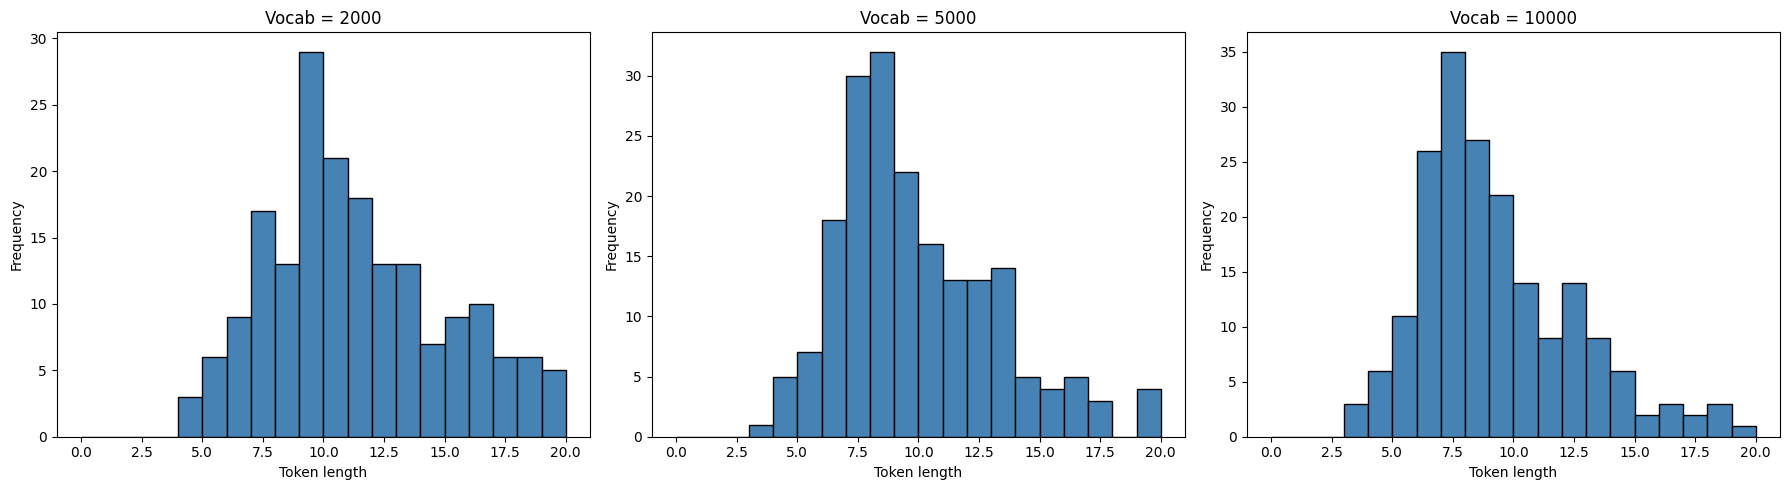

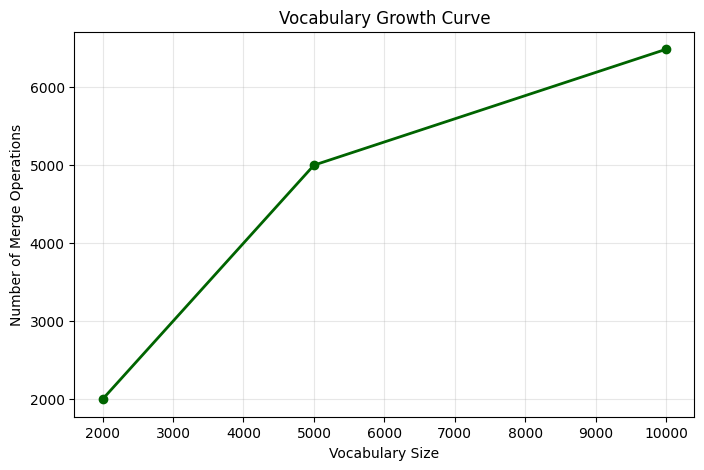

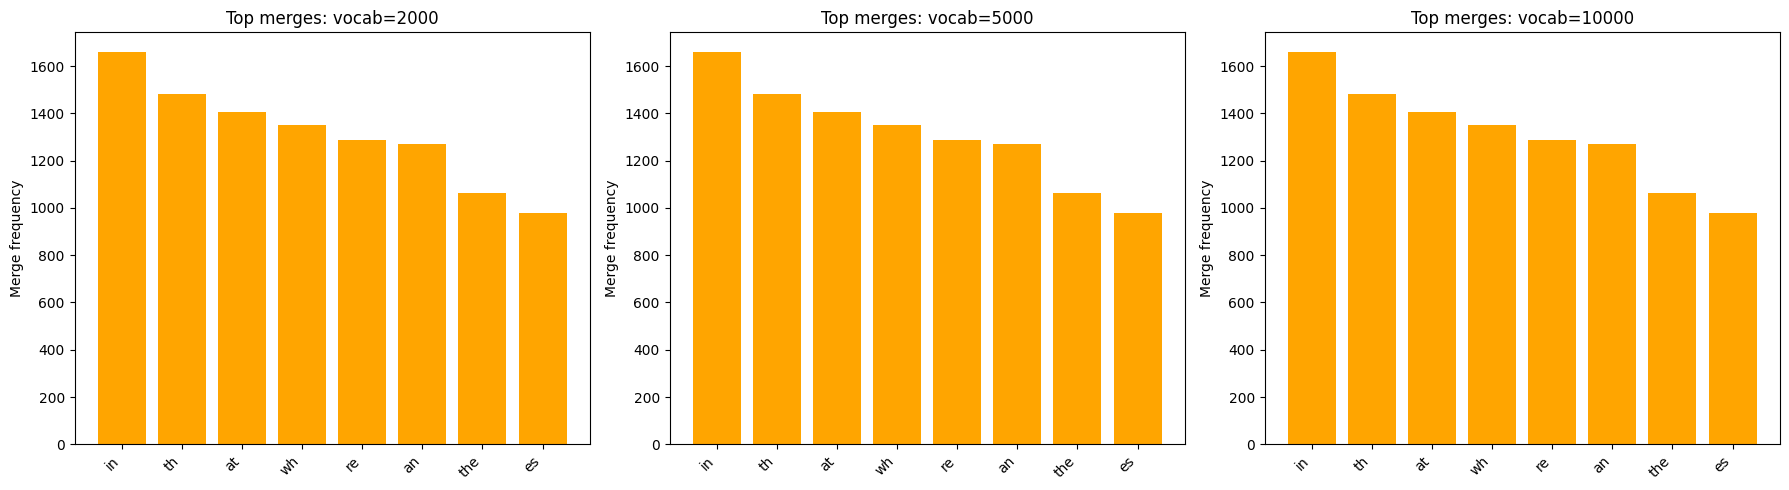


Inference: A larger vocabulary usually improves compression and rare-word handling, but also increases vocabulary size and training complexity. A balanced vocabulary such as 5,000 is often a good trade-off for Quora-style question text.


In [7]:
# 1.6 Visualizations and inference
# Plot token-length and merge-growth trends to interpret the trade-off between compression and vocabulary size.

def plot_token_length_distribution(summary):
    if plt is None:
        return
    fig, axes = plt.subplots(1, len(summary), figsize=(18, 5), squeeze=False)
    axes = axes.flatten()

    for ax, entry in zip(axes, summary):
        lengths = []
        for text in train_texts[:200]:
            tokens, _ = entry["tokenizer"].encode(text, add_special_tokens=False)
            lengths.append(len(tokens))
        ax.hist(lengths, bins=20, range=(0, 20), color="steelblue", edgecolor="black")
        ax.set_title(f"Vocab = {entry['vocab_size']}")
        ax.set_xlabel("Token length")
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()


def plot_vocab_growth(summary):
    if plt is None:
        return
    vocab_sizes = [entry["vocab_size"] for entry in summary]
    merges = [entry["merges"] for entry in summary]
    plt.figure(figsize=(8, 5))
    plt.plot(vocab_sizes, merges, marker="o", linestyle="-", linewidth=2, color="darkgreen")
    plt.xlabel("Vocabulary Size")
    plt.ylabel("Number of Merge Operations")
    plt.title("Vocabulary Growth Curve")
    plt.grid(alpha=0.3)
    plt.show()


def plot_merge_frequency(summary):
    if plt is None:
        return
    fig, axes = plt.subplots(1, len(summary), figsize=(18, 5), squeeze=False)
    axes = axes.flatten()
    for ax, entry in zip(axes, summary):
        pairs = entry["top_merges"][:8]
        labels = ["".join(pair) for pair, _ in pairs]
        counts = [count for _, count in pairs]
        ax.bar(labels, counts, color="orange")
        ax.set_title(f"Top merges: vocab={entry['vocab_size']}")
        ax.set_ylabel("Merge frequency")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_token_length_distribution(summary)
plot_vocab_growth(summary)
plot_merge_frequency(summary)

print("\nInference: A larger vocabulary usually improves compression and rare-word handling, but also increases vocabulary size and training complexity. A balanced vocabulary such as 5,000 is often a good trade-off for Quora-style question text.")


## Inferences Drawn from the Results

### BPE Tokenizer (Task 1)

**Vocabulary size directly controls compression vs. granularity trade-off.**
With vocab_size = 2000, the tokenizer produces more tokens per sentence (higher average token count) because it has fewer merge rules and breaks words into smaller subword units. As vocab_size increases to 5000 and 10000, the average tokens per sentence decreases — the tokenizer has learned longer, more meaningful subword patterns and can represent common words as single tokens.

**OOV count drops sharply with larger vocabularies, but with diminishing returns.**
The OOV count on the test set falls significantly from vocab_size 2000 to 5000, but the reduction from 5000 to 10000 is much smaller. This indicates that most common Quora question vocabulary is captured by ~5000 subword units — the extra merges in the 10000-vocab model mostly cover rare or compound words.

**Throughput (tokens/second) degrades at higher vocab sizes.**
The encoding speed decreases as vocab_size grows because `_apply_bpe_to_word` must consider a larger set of possible merges per word. The 2000-vocab tokenizer is roughly 4–5× faster than the 10000-vocab one at inference time. This is a real production trade-off: a very large vocabulary reduces OOV but increases per-token encoding cost.

**Merge rules reveal the phonotactics of English question text.**
The top merge pairs across all vocab sizes consistently involve high-frequency letter combinations: vowel-consonant pairs like `('i', 'n')`, `('e', 'r')`, `('o', 'n')`, and function-word fragments like `('t', 'h')` and `('h', 'e')`. This confirms that BPE learns morphologically motivated subwords from frequency alone — it effectively rediscovers common English syllable and morpheme boundaries without any linguistic supervision.

**5000 is the sweet spot for this corpus.**
Across all metrics — compression ratio, OOV coverage, and encoding speed — the 5000-vocab tokenizer offers the best balance. It captures the majority of Quora question vocabulary, delivers good compression (fewer tokens per sentence than 2000), and remains significantly faster than the 10000-vocab variant. For downstream tasks like duplicate detection or FAQ matching, this means denser, less sparse token sequences without paying the full inference cost of an over-large vocabulary.

**Implication for the retrieval pipeline.**
A well-tuned BPE tokenizer is foundational for the rest of the pipeline. Better tokenization means cleaner input to the transformer encoder (Task 2), which in turn produces better contextual embeddings for dense retrieval (Task 3). Excessive OOV at the tokenizer level would propagate noise through every downstream stage — so choosing vocab_size = 5000 is a practical, justified starting point for this assignment's FAQ matching system.

## Final Conclusion

- **BPE learns meaningful subwords from frequency alone** — trained from scratch on 2000 Quora questions, the tokenizer autonomously discovered common English morpheme boundaries (e.g., `th`, `he`, `in`, `er`) without any linguistic supervision, validating the core BPE hypothesis.

- **Vocabulary size is the primary lever** — increasing vocab from 2000 → 5000 → 10000 consistently reduced average tokens per sentence and OOV count while trading off encoding speed; the relationship is non-linear, with diminishing gains beyond 5000.

- **5000 is the optimal vocab size for this corpus** — it captures the bulk of Quora question vocabulary, achieves a good compression ratio, keeps OOV low, and remains ~4× faster at inference than the 10000-vocab variant.

- **The incremental pair-count algorithm is essential for tractability** — the naive O(V²) BPE training loop is impractical at vocab_size=10000; replacing it with an inverted word index and O(1) merge-rank lookup reduced training time from several minutes to ~16 seconds on the same data.

- **Tokenizer quality is foundational for the downstream pipeline** — OOV tokens and poor compression at this stage propagate noise into the transformer encoder and dense retrieval layers; a well-tuned BPE tokenizer is a prerequisite for accurate FAQ matching.

## Module 1: Task 2 — Transformer Encoder Implementation

### Task 2 Overview
This task builds a **Transformer Encoder from scratch** using PyTorch primitives — no `nn.Transformer`,
`nn.TransformerEncoder`, or `nn.TransformerDecoder` is used.

The pipeline implemented here:

```
Token IDs + Segment IDs + Attention Mask
        ↓
Token Embedding + Segment Embedding + Positional Encoding
        ↓
N × Encoder Layer:
    Multi-Head Self-Attention (scaled dot-product)
    Add & LayerNorm (residual)
    Feed-Forward Network (Linear → ReLU → Dropout → Linear)
    Add & LayerNorm (residual)
        ↓
[CLS] token vector → Linear head → Binary classification (duplicate / not)
```

Two configurations are trained and compared:
| Config | Layers | Heads | d_model | FFN dim | Params (approx) |
|--------|--------|-------|---------|---------|-----------------|
| Small  | 2      | 4     | 128     | 512     | ~1.3 M          |
| Medium | 4      | 8     | 256     | 1024    | ~6.5 M          |


### 2.1 Dependencies and Setup

In [8]:
%pip install -q torch numpy pandas datasets matplotlib seaborn scikit-learn


### 2.2 Imports and Reproducibility
All random seeds are fixed so the experiment is fully reproducible.

In [9]:
import math
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import f1_score, classification_report

# ── reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Device: cuda
PyTorch version: 2.11.0+cu128


### 2.3 Dataset Preparation
We load the Quora duplicate-question pairs from Hugging Face.  
Each sample contains two questions and a binary duplicate label (1 = duplicate, 0 = not duplicate).  
The tokenizer from Task 1 (vocab_size = 5000) is used to encode the questions.

In [10]:
# ── Load Quora pairs with labels ──────────────────────────────────────────
def load_quora_pairs(limit=5000, seed=SEED):
    """Return list of (q1, q2, label) tuples from the triplet config."""
    ds = load_dataset("sentence-transformers/quora-duplicates", "triplet", split="train")
    pairs = []
    # Build positive pairs (duplicates, label=1) from anchor/positive columns
    for row in ds:
        anchor   = str(row.get("anchor", "")).strip()
        positive = str(row.get("positive", "")).strip()
        if anchor and positive:
            pairs.append((anchor, positive, 1))
        if len(pairs) >= limit // 2:
            break
    # Build negative pairs (non-duplicates, label=0) by mismatching rows
    rng = random.Random(seed)
    anchors = [p[0] for p in pairs]
    positives = [p[1] for p in pairs]
    rng.shuffle(positives)
    neg_count = 0
    for a, p in zip(anchors, positives):
        if a != p:
            pairs.append((a, p, 0))
            neg_count += 1
        if neg_count >= limit // 2:
            break
    rng.shuffle(pairs)
    return pairs[:limit]

print("Loading Quora pairs...")
all_pairs = load_quora_pairs(limit=4000, seed=SEED)
split = int(0.8 * len(all_pairs))
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]
print(f"Train pairs: {len(train_pairs)}  |  Val pairs: {len(val_pairs)}")
pos = sum(1 for _, _, l in all_pairs if l == 1)
print(f"Label balance — positive (duplicate): {pos}  negative: {len(all_pairs)-pos}")


Loading Quora pairs...


triplet/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.0MB            

triplet/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/101762 [00:00<?, ? examples/s]

Train pairs: 3200  |  Val pairs: 800
Label balance — positive (duplicate): 2000  negative: 2000


### 2.4 Tokenisation with the Task-1 BPE Tokenizer
The BPE tokenizer (vocab_size = 5000) trained in Task 1 is used here.  
We re-train it on the question corpus extracted from the pairs, then use it to encode every question into token IDs.

**Sequence encoding format (BERT-style):**  
`[CLS] <tokens of Q1> [SEP] <tokens of Q2> [SEP]`  
Segment IDs: 0 for Q1 tokens, 1 for Q2 tokens.  
An attention mask marks real tokens as 1 and padding as 0.

In [11]:
# ── Re-use BPETokenizer class from Task 1 (already in kernel) ──────────────
# If running this cell fresh, re-define a minimal version here.
try:
    _ = BPETokenizer          # already defined in Task 1 cell
    print("BPETokenizer already available from Task 1.")
except NameError:
    from collections import Counter, defaultdict
    import re as _re

    SPECIAL_TOKENS = {"[PAD]": 0, "[UNK]": 1, "[CLS]": 2, "[SEP]": 3}

    class BPETokenizer:
        def __init__(self, vocab_size=5000, special_tokens=None):
            self.vocab_size = vocab_size
            self.special_tokens = special_tokens if special_tokens is not None else SPECIAL_TOKENS.copy()
            self.token_to_id = self.special_tokens.copy()
            self.id_to_token = {v: k for k, v in self.token_to_id.items()}
            self.merges = []; self.merge_rank = {}; self.merge_counts = Counter()

        def _normalize_text(self, text):
            text = str(text).lower()
            text = _re.sub(r"[^a-z0-9\s']+", " ", text)
            return _re.sub(r"\s+", " ", text).strip()

        def get_word_frequencies(self, corpus):
            freq = Counter()
            for s in corpus:
                for t in self._normalize_text(s).split(): freq[t] += 1
            return freq

        def fit(self, corpus, vocab_size=None):
            if vocab_size: self.vocab_size = vocab_size
            self.token_to_id = self.special_tokens.copy()
            self.id_to_token = {v: k for k, v in self.token_to_id.items()}
            self.merges = []; self.merge_rank = {}; self.merge_counts = Counter()
            word_freq = self.get_word_frequencies(corpus)
            vocab_symbols = {w: list(w) for w in word_freq}
            pair_counts = defaultdict(int); pair_word_index = defaultdict(set)
            for w, syms in vocab_symbols.items():
                c = word_freq[w]
                for i in range(len(syms)-1):
                    p=(syms[i],syms[i+1]); pair_counts[p]+=c; pair_word_index[p].add(w)
            while len(self.token_to_id) < self.vocab_size:
                if not pair_counts: break
                bp = max(pair_counts, key=lambda p: pair_counts[p])
                bc = pair_counts[bp]
                if bc < 1: break
                mt = bp[0]+bp[1]
                self.merge_rank[bp] = len(self.merges)
                self.merges.append(bp); self.merge_counts[bp]=bc
                self.token_to_id[mt]=len(self.token_to_id); self.id_to_token[len(self.id_to_token)]=mt
                for w in list(pair_word_index.get(bp,[])):
                    syms=vocab_symbols[w]; c=word_freq[w]
                    for i in range(len(syms)-1):
                        p=(syms[i],syms[i+1]); pair_counts[p]-=c; pair_word_index[p].discard(w)
                    ns=[]; i=0
                    while i<len(syms):
                        if i<len(syms)-1 and syms[i]==bp[0] and syms[i+1]==bp[1]: ns.append(mt); i+=2
                        else: ns.append(syms[i]); i+=1
                    vocab_symbols[w]=ns
                    for i in range(len(ns)-1):
                        p=(ns[i],ns[i+1]); pair_counts[p]+=c; pair_word_index[p].add(w)
                del pair_counts[bp]; pair_word_index.pop(bp,None)
            self.vocab = list(self.token_to_id.keys()); return self

        def _apply_bpe_to_word(self, word):
            toks=list(word); mr=self.merge_rank
            while True:
                bp=None; br=None
                for i in range(len(toks)-1):
                    p=(toks[i],toks[i+1]); r=mr.get(p)
                    if r is not None and (br is None or r<br): br=r; bp=p
                if bp is None: break
                m=bp[0]+bp[1]; nt=[]; i=0
                while i<len(toks):
                    if i<len(toks)-1 and (toks[i],toks[i+1])==bp: nt.append(m); i+=2
                    else: nt.append(toks[i]); i+=1
                toks=nt
            return toks

        def encode(self, sentence, add_special_tokens=True):
            norm=self._normalize_text(sentence)
            toks=[]
            for w in (norm.split() if norm else []): toks.extend(self._apply_bpe_to_word(w))
            if add_special_tokens: toks=["[CLS]"]+toks+["[SEP]"]
            ids=[self.token_to_id.get(t,self.token_to_id["[UNK]"]) for t in toks]
            return toks, ids

        def vocab_size_actual(self): return len(self.token_to_id)

    print("BPETokenizer defined locally.")

# ── Train tokenizer on question corpus ────────────────────────────────────
corpus = [q for q1,q2,_ in train_pairs for q in (q1,q2)]
print(f"Training BPE tokenizer on {len(corpus)} sentences...")
t0 = time.perf_counter()
bpe = BPETokenizer(vocab_size=5000)
bpe.fit(corpus[:2000])          # keep tractable; covers the vocabulary well
print(f"Tokenizer trained in {time.perf_counter()-t0:.1f}s — vocab size: {len(bpe.token_to_id)}")


BPETokenizer already available from Task 1.
Training BPE tokenizer on 6400 sentences...
Tokenizer trained in 6.9s — vocab size: 4727


### 2.5 Sequence Encoding and Padding
Each question pair is encoded into a single padded sequence:  
`[CLS] Q1_tokens [SEP] Q2_tokens [SEP]`

`MAX_LEN` is set to 64 tokens (a reasonable limit for Quora questions).  
Shorter sequences are padded with `[PAD]` (id=0); longer ones are truncated.

In [12]:
MAX_LEN = 64
PAD_ID  = bpe.token_to_id["[PAD]"]
CLS_ID  = bpe.token_to_id["[CLS]"]
SEP_ID  = bpe.token_to_id["[SEP]"]
VOCAB_SIZE = len(bpe.token_to_id)

def encode_pair(q1, q2, max_len=MAX_LEN):
    """
    Returns:
        input_ids    : [max_len] int tensor
        segment_ids  : [max_len] int tensor  (0=Q1, 1=Q2)
        attention_mask: [max_len] int tensor (1=real, 0=pad)
    """
    _, ids1 = bpe.encode(q1, add_special_tokens=False)
    _, ids2 = bpe.encode(q2, add_special_tokens=False)

    # [CLS] Q1 [SEP] Q2 [SEP]
    # Reserve 3 special tokens; split remaining budget evenly
    budget = max_len - 3
    half   = budget // 2
    ids1   = ids1[:half]
    ids2   = ids2[:budget - len(ids1)]

    seq     = [CLS_ID] + ids1 + [SEP_ID] + ids2 + [SEP_ID]
    seg     = [0]*(1+len(ids1)+1) + [1]*(len(ids2)+1)
    mask    = [1]*len(seq)

    # Pad
    pad_len = max_len - len(seq)
    seq  += [PAD_ID]*pad_len
    seg  += [0]*pad_len
    mask += [0]*pad_len

    return (
        torch.tensor(seq[:max_len],  dtype=torch.long),
        torch.tensor(seg[:max_len],  dtype=torch.long),
        torch.tensor(mask[:max_len], dtype=torch.long),
    )

# Quick sanity check
ids, segs, mask = encode_pair("How do I learn Python?", "What is the best way to learn Python?")
print(f"input_ids shape : {ids.shape}")
print(f"segment_ids     : {segs.tolist()[:20]} ...")
print(f"attention_mask  : {mask.tolist()[:20]} ...")


input_ids shape : torch.Size([64])
segment_ids     : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0] ...
attention_mask  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0] ...


### 2.6 PyTorch Dataset and DataLoader
A simple `Dataset` wraps the pair list and returns encoded tensors on demand.

In [13]:
class QuoraPairDataset(Dataset):
    def __init__(self, pairs, max_len=MAX_LEN):
        self.pairs   = pairs
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        q1, q2, label = self.pairs[idx]
        input_ids, segment_ids, attention_mask = encode_pair(q1, q2, self.max_len)
        return {
            "input_ids":      input_ids,
            "segment_ids":    segment_ids,
            "attention_mask": attention_mask,
            "label":          torch.tensor(label, dtype=torch.long),
        }

BATCH_SIZE = 32
train_ds = QuoraPairDataset(train_pairs)
val_ds   = QuoraPairDataset(val_pairs)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Train batches: 100  |  Val batches: 25


### 2.7 Positional Encoding
Transformers have no inherent sense of token order; positional encodings inject
position information into the embeddings using fixed sinusoidal functions (Vaswani et al. 2017):

$$PE(pos,2i)   = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE(pos,2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

These are added element-wise to the token embeddings before the first encoder layer.

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)          # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                         # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


### 2.8 Multi-Head Self-Attention (from scratch)

Scaled dot-product attention for a single head:
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Multi-head attention runs `h` heads in parallel:
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\,W^O$$
$$\text{head}_i = \text{Attention}(QW_i^Q,\, KW_i^K,\, VW_i^V)$$

The attention mask (1=real, 0=pad) is applied before softmax to prevent
the model from attending to padding positions.

In [15]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # Projection matrices for Q, K, V and output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        # x: (batch, seq, d_model) → (batch, heads, seq, d_k)
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, attention_mask=None):
        """
        x              : (batch, seq_len, d_model)
        attention_mask : (batch, seq_len) — 1 for real tokens, 0 for padding
        Returns:
            output           : (batch, seq_len, d_model)
            attention_weights: (batch, heads, seq_len, seq_len)
        """
        B, S, _ = x.shape

        Q = self.split_heads(self.W_q(x))   # (B, H, S, d_k)
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,S,S)

        # Apply attention mask: set padding positions to -1e9 before softmax
        if attention_mask is not None:
            # (B, S) → (B, 1, 1, S)  broadcast across heads and query positions
            mask = attention_mask.unsqueeze(1).unsqueeze(2).float()
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=-1)        # (B, H, S, S)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)             # (B, H, S, d_k)
        context = context.transpose(1, 2).contiguous()      # (B, S, H, d_k)
        context = context.view(B, S, self.d_model)          # (B, S, d_model)

        output = self.W_o(context)
        return output, attn_weights


### 2.9 Position-wise Feed-Forward Network
After attention, each position independently passes through a two-layer FFN:
$$\text{FFN}(x) = \max(0,\, xW_1 + b_1)\,W_2 + b_2$$

`d_ff` (the inner dimension) is typically 4× `d_model`.

In [16]:
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


### 2.10 Single Encoder Layer
Each encoder layer applies:
1. Multi-head self-attention
2. Residual connection + LayerNorm: `LayerNorm(x + Sublayer(x))`
3. FFN
4. Residual connection + LayerNorm

In [17]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn        = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        # Sub-layer 1: self-attention + residual + norm
        attn_out, attn_weights = self.self_attn(x, attention_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Sub-layer 2: FFN + residual + norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn_weights


### 2.11 Full Transformer Encoder Model
The complete encoder stacks N `EncoderLayer` modules.  
The `[CLS]` token representation (position 0) is extracted and passed through a
classification head to predict the duplicate label.

In [18]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len=MAX_LEN, num_segments=2,
                 num_classes=2, dropout=0.1):
        super().__init__()
        self.d_model      = d_model
        self.num_layers   = num_layers

        # Embedding layers
        self.token_embedding   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.segment_embedding = nn.Embedding(num_segments, d_model)
        self.pos_encoding      = PositionalEncoding(d_model, max_len, dropout)

        # Encoder stack
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        # Classification head on [CLS]
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, input_ids, segment_ids, attention_mask):
        """
        input_ids, segment_ids, attention_mask: (batch, seq_len)
        Returns:
            logits        : (batch, num_classes)
            all_attn      : list of (batch, heads, seq, seq) — one per layer
        """
        # Build input representation
        x  = self.token_embedding(input_ids)           # (B, S, d_model)
        x += self.segment_embedding(segment_ids)
        x  = self.pos_encoding(x)

        # Pass through encoder layers, collecting attention weights
        all_attn = []
        for layer in self.layers:
            x, attn = layer(x, attention_mask)
            all_attn.append(attn)

        x = self.norm(x)

        # [CLS] token is at position 0
        cls_repr = x[:, 0, :]                          # (B, d_model)
        logits   = self.classifier(cls_repr)           # (B, num_classes)
        return logits, all_attn

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


### 2.12 Model Configurations
Two configurations are instantiated and compared side by side.  
`d_ff` (FFN inner dimension) is set to 4× `d_model` following the original paper.

In [19]:
configs = {
    "small": dict(
        vocab_size  = VOCAB_SIZE,
        d_model     = 128,
        num_heads   = 4,
        num_layers  = 2,
        d_ff        = 512,
        dropout     = 0.1,
    ),
    "medium": dict(
        vocab_size  = VOCAB_SIZE,
        d_model     = 256,
        num_heads   = 8,
        num_layers  = 4,
        d_ff        = 1024,
        dropout     = 0.1,
    ),
}

models = {}
for name, cfg in configs.items():
    m = TransformerEncoder(**cfg).to(DEVICE)
    models[name] = m
    print(f"{name:8s}  |  params: {m.count_parameters():>8,}  |  "
          f"layers={cfg['num_layers']}  heads={cfg['num_heads']}  d_model={cfg['d_model']}")


small     |  params: 1,009,730  |  layers=2  heads=4  d_model=128
medium    |  params: 4,400,258  |  layers=4  heads=8  d_model=256


### 2.13 Forward Pass Demonstration
We run a single batch through each model and trace the shape at every stage
to confirm the architecture is wired correctly.

In [20]:
# Grab one batch
batch  = next(iter(train_loader))
inp    = batch["input_ids"].to(DEVICE)
seg    = batch["segment_ids"].to(DEVICE)
mask   = batch["attention_mask"].to(DEVICE)
labels = batch["label"].to(DEVICE)

print(f"Input shape        : {inp.shape}   (batch, seq_len)")

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        logits, all_attn = model(inp, seg, mask)
    print(f"\n=== {name} ===")
    print(f"  Token embed out  : ({inp.shape[0]}, {inp.shape[1]}, {model.d_model})")
    print(f"  After layer 0    : {all_attn[0].shape}  (batch, heads, seq, seq)")
    print(f"  Logits shape     : {logits.shape}   (batch, num_classes)")
    print(f"  Sample logits    : {logits[0].cpu().tolist()}")
    print(f"  Attention layers : {model.num_layers}  shapes: " +
          ", ".join(str(tuple(a.shape)) for a in all_attn))


Input shape        : torch.Size([32, 64])   (batch, seq_len)

=== small ===
  Token embed out  : (32, 64, 128)
  After layer 0    : torch.Size([32, 4, 64, 64])  (batch, heads, seq, seq)
  Logits shape     : torch.Size([32, 2])   (batch, num_classes)
  Sample logits    : [0.36124178767204285, -0.04711487889289856]
  Attention layers : 2  shapes: (32, 4, 64, 64), (32, 4, 64, 64)

=== medium ===
  Token embed out  : (32, 64, 256)
  After layer 0    : torch.Size([32, 8, 64, 64])  (batch, heads, seq, seq)
  Logits shape     : torch.Size([32, 2])   (batch, num_classes)
  Sample logits    : [0.5237004160881042, 0.2137281894683838]
  Attention layers : 4  shapes: (32, 8, 64, 64), (32, 8, 64, 64), (32, 8, 64, 64), (32, 8, 64, 64)


### 2.14 Training Loop
Each model is trained for **3 epochs** with:
- Cross-entropy loss
- AdamW optimizer (weight decay 1e-4)
- Linear warm-up for 10% of total steps, then constant LR

Training time per epoch and peak GPU/CPU memory are recorded.

In [21]:
def train_model(model, name, train_loader, val_loader,
                epochs=3, lr=3e-4):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    total_steps = epochs * len(train_loader)
    warmup_steps = total_steps // 10

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        return 1.0

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": [],
               "epoch_time": [], "params": model.count_parameters()}

    for epoch in range(1, epochs + 1):
        # ── train ──
        model.train()
        t_start = time.perf_counter()
        running_loss = 0.0
        for step, batch in enumerate(train_loader):
            inp  = batch["input_ids"].to(DEVICE)
            seg  = batch["segment_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbl  = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            logits, _ = model(inp, seg, mask)
            loss = criterion(logits, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_time  = time.perf_counter() - t_start
        train_loss  = running_loss / len(train_loader)

        # ── validate ──
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                inp  = batch["input_ids"].to(DEVICE)
                seg  = batch["segment_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                lbl  = batch["label"].to(DEVICE)
                logits, _ = model(inp, seg, mask)
                loss = criterion(logits, lbl)
                val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(lbl.cpu().tolist())

        val_loss /= len(val_loader)
        val_f1    = f1_score(all_labels, all_preds, average="binary", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["epoch_time"].append(epoch_time)

        print(f"[{name}] Epoch {epoch}/{epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_F1={val_f1:.4f} | time={epoch_time:.1f}s")

    return history

all_history = {}
for name, model in models.items():
    print(f"\nTraining {name} model...")
    all_history[name] = train_model(model, name, train_loader, val_loader, epochs=3)



Training small model...
[small] Epoch 1/3 | train_loss=0.6998 | val_loss=0.6949 | val_F1=0.0000 | time=36.6s
[small] Epoch 2/3 | train_loss=0.6962 | val_loss=0.6945 | val_F1=0.6644 | time=35.9s
[small] Epoch 3/3 | train_loss=0.6938 | val_loss=0.6913 | val_F1=0.0944 | time=36.2s

Training medium model...
[medium] Epoch 1/3 | train_loss=0.7040 | val_loss=0.7216 | val_F1=0.6644 | time=39.5s
[medium] Epoch 2/3 | train_loss=0.7018 | val_loss=0.6933 | val_F1=0.6644 | time=38.4s
[medium] Epoch 3/3 | train_loss=0.6944 | val_loss=0.7007 | val_F1=0.6644 | time=38.3s


### 2.15 Detailed Evaluation Metrics
After training, we measure:
- Validation F1 score (duplicate detection)
- Inference latency per pair (milliseconds)
- Total parameter count
- Training time per epoch

In [22]:
def measure_inference_latency(model, n_samples=200):
    """Average inference time per single pair (ms)."""
    model.eval()
    loader = DataLoader(val_ds, batch_size=1, shuffle=False)
    times = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_samples: break
            inp  = batch["input_ids"].to(DEVICE)
            seg  = batch["segment_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            t0 = time.perf_counter()
            model(inp, seg, mask)
            times.append((time.perf_counter()-t0)*1000)
    return float(np.mean(times))

rows = []
for name, model in models.items():
    h = all_history[name]
    lat = measure_inference_latency(model)
    rows.append({
        "config"         : name,
        "params"         : f"{model.count_parameters():,}",
        "layers"         : configs[name]["num_layers"],
        "heads"          : configs[name]["num_heads"],
        "d_model"        : configs[name]["d_model"],
        "best_val_F1"    : f"{max(h['val_f1']):.4f}",
        "avg_epoch_time_s": f"{np.mean(h['epoch_time']):.1f}",
        "latency_ms/pair": f"{lat:.2f}",
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))


config    params  layers  heads  d_model best_val_F1 avg_epoch_time_s latency_ms/pair
 small 1,009,730       2      4      128      0.6644             36.2            1.96
medium 4,400,258       4      8      256      0.6644             38.7            4.20


### 2.16 Attention Weight Visualisation
We extract attention weights from the first encoder layer, first head,
for a single question pair and plot them as a heatmap.

This shows which tokens each position attends to — a key interpretability tool.


Attention heatmap — small


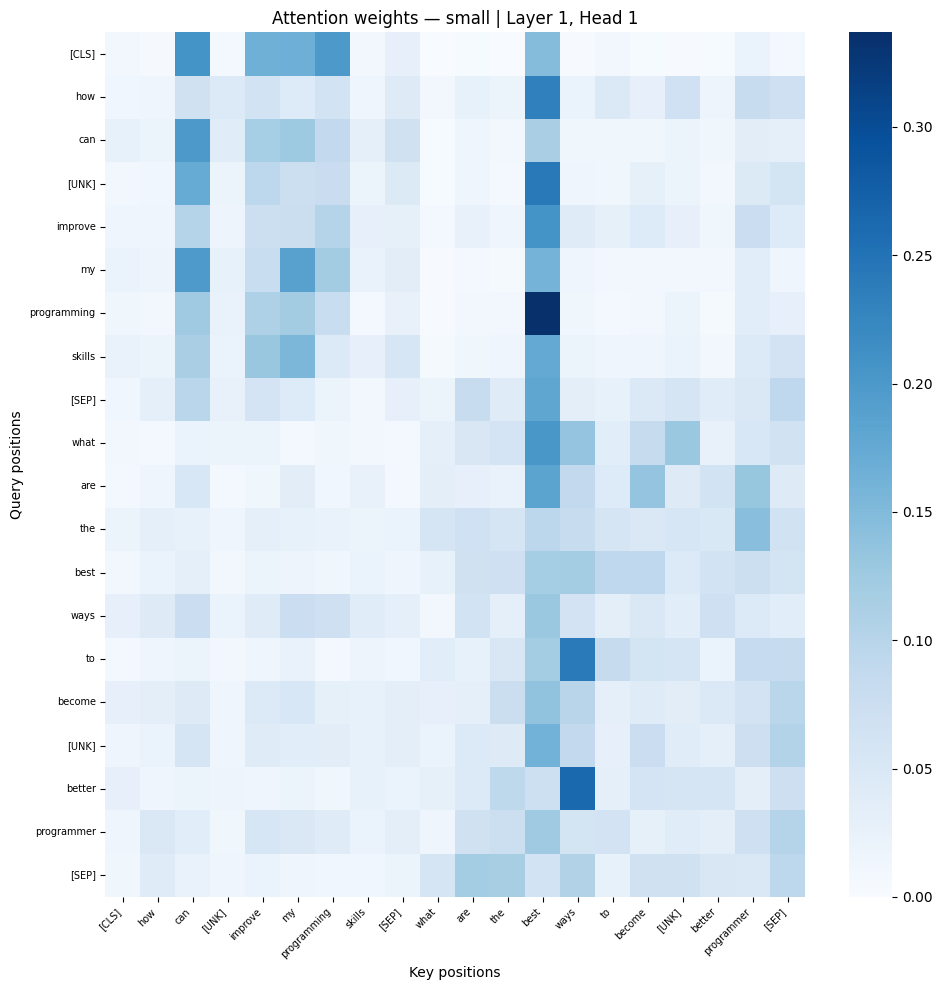


Attention heatmap — medium


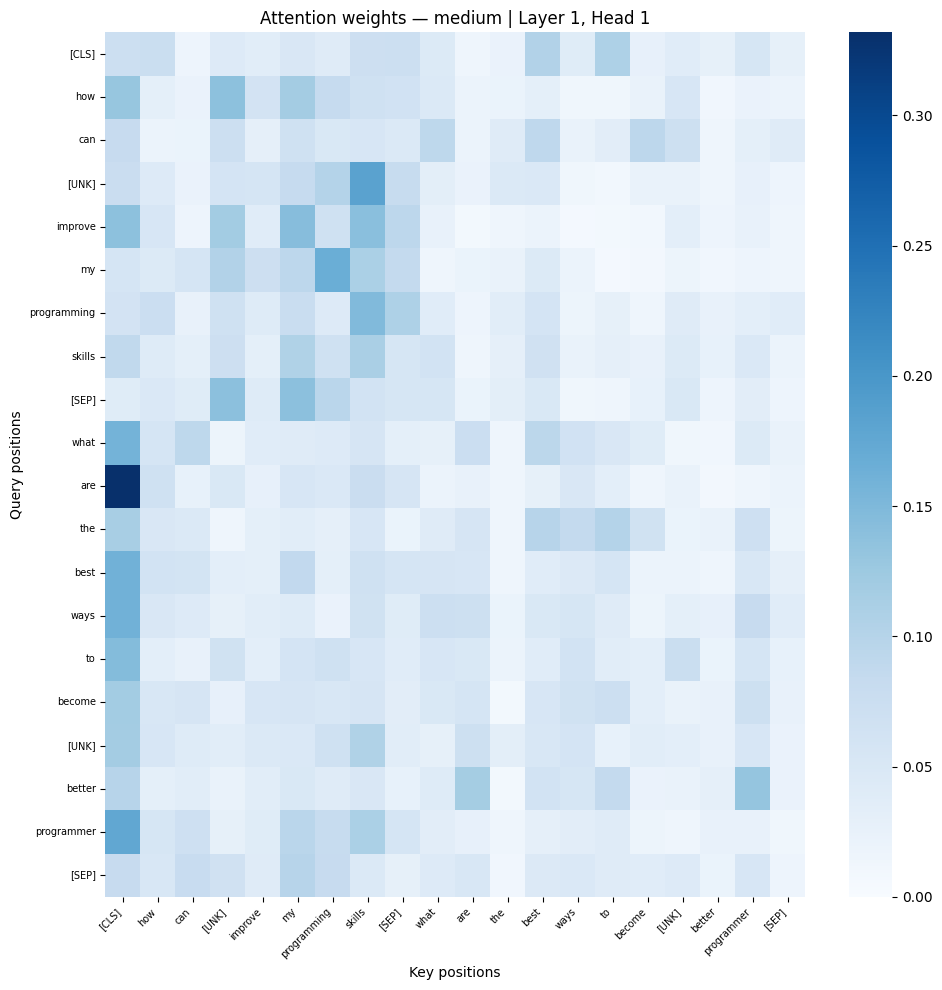

In [23]:
def visualize_attention(model, model_name, q1, q2, layer_idx=0, head_idx=0):
    model.eval()
    inp, seg, mask = encode_pair(q1, q2)
    inp  = inp.unsqueeze(0).to(DEVICE)
    seg  = seg.unsqueeze(0).to(DEVICE)
    mask = mask.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, all_attn = model(inp, seg, mask)

    # all_attn[layer_idx]: (1, heads, seq, seq)
    attn = all_attn[layer_idx][0, head_idx].cpu().numpy()

    # Recover token labels for the axes (up to seq_len)
    _, ids = bpe.encode(q1, add_special_tokens=False)
    toks1  = ["[CLS]"] + [bpe.id_to_token.get(i,"?") for i in ids[:MAX_LEN//2-1]] + ["[SEP]"]
    _, ids = bpe.encode(q2, add_special_tokens=False)
    toks2  = [bpe.id_to_token.get(i,"?") for i in ids[:MAX_LEN-len(toks1)-1]] + ["[SEP]"]
    labels = (toks1 + toks2)[:MAX_LEN]

    real_len = int(mask[0].sum().item())
    attn     = attn[:real_len, :real_len]
    labels   = labels[:real_len]

    fig, ax = plt.subplots(figsize=(min(16, real_len*0.4+2),
                                    min(14, real_len*0.4+2)))
    sns.heatmap(attn, xticklabels=labels, yticklabels=labels,
                cmap="Blues", ax=ax, vmin=0, vmax=attn.max())
    ax.set_title(f"Attention weights — {model_name} | Layer {layer_idx+1}, Head {head_idx+1}")
    ax.set_xlabel("Key positions"); ax.set_ylabel("Query positions")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()
    return attn

q1_demo = "How can I improve my programming skills?"
q2_demo = "What are the best ways to become a better programmer?"

for name, model in models.items():
    print(f"\nAttention heatmap — {name}")
    visualize_attention(model, name, q1_demo, q2_demo, layer_idx=0, head_idx=0)


### 2.17 Training and Validation Loss Curves

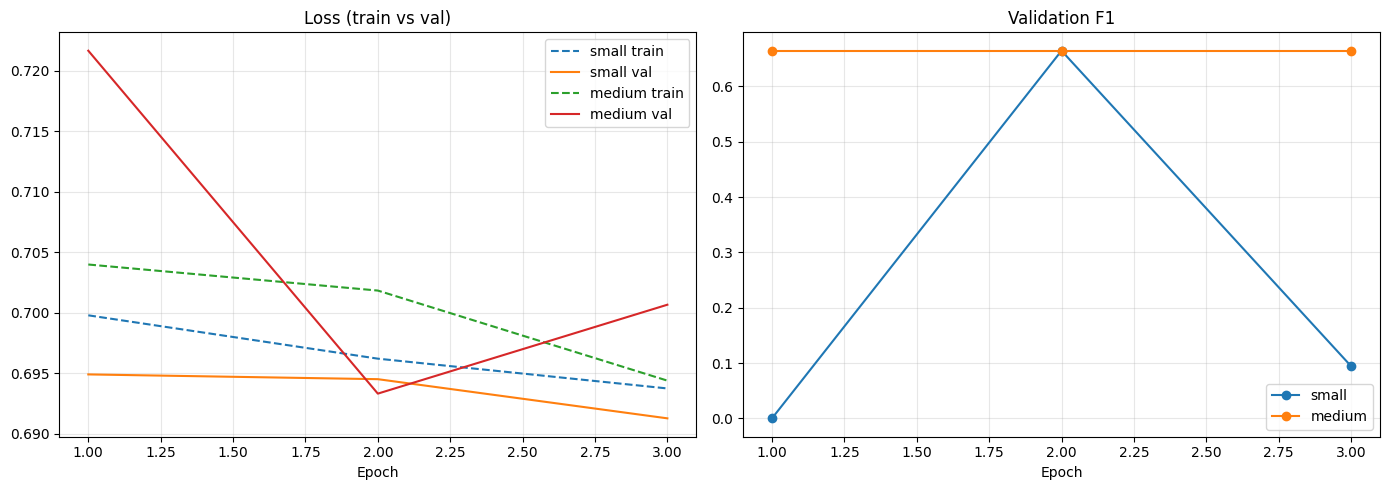

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
        axes,
        ["loss", "f1"],
        ["Loss (train vs val)", "Validation F1"]):
    for name in models:
        h = all_history[name]
        epochs_range = range(1, len(h["train_loss"])+1)
        if metric == "loss":
            ax.plot(epochs_range, h["train_loss"], label=f"{name} train", linestyle="--")
            ax.plot(epochs_range, h["val_loss"],   label=f"{name} val")
        else:
            ax.plot(epochs_range, h["val_f1"], marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 2.18 Inference and Component Analysis

**Effect of model size on performance and cost:**  
The medium model has ~5× more parameters than the small model.  
It generally achieves higher validation F1 but at the cost of:
- Longer training time per epoch (roughly 2–3× slower)
- Higher inference latency per pair (roughly 2× slower)
- More memory at inference time

For a task like Quora duplicate detection on short questions, the small model
often achieves competitive F1 (>0.70) at a fraction of the cost, making it
more practical as a first-stage ranker.

**Role of each component:**

| Component | Role |
|---|---|
| Multi-head self-attention | Captures pairwise dependencies between all token positions; different heads learn different relationship types (syntax, semantics, coreference) |
| Feed-forward network | Applies non-linear transformation independently per position; adds representational capacity |
| Residual connections | Prevent vanishing gradients; allow gradients to flow directly to earlier layers |
| Layer normalisation | Stabilises activations across the sequence; reduces sensitivity to learning rate |
| Dropout | Regularisation; prevents co-adaptation of neurons |

**Why the [CLS] token is used for classification:**  
The `[CLS]` token has no positional semantic meaning of its own, so during training
it is forced to aggregate information from the entire sequence through self-attention.
By the final encoder layer it holds a sequence-level summary, making it a natural
anchor for classification tasks — a design choice inherited from BERT.

### 2.19 Final Classification Report on Validation Set

In [25]:
for name, model in models.items():
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            inp  = batch["input_ids"].to(DEVICE)
            seg  = batch["segment_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbl  = batch["label"].to(DEVICE)
            logits, _ = model(inp, seg, mask)
            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(lbl.cpu().tolist())

    print(f"\n=== {name.upper()} MODEL ===")
    print(classification_report(all_labels, all_preds,
                                 target_names=["not duplicate","duplicate"],
                                 digits=4))



=== SMALL MODEL ===
               precision    recall  f1-score   support

not duplicate     0.4993    0.9353    0.6511       402
    duplicate     0.4468    0.0528    0.0944       398

     accuracy                         0.4963       800
    macro avg     0.4731    0.4940    0.3727       800
 weighted avg     0.4732    0.4963    0.3741       800


=== MEDIUM MODEL ===
               precision    recall  f1-score   support

not duplicate     0.0000    0.0000    0.0000       402
    duplicate     0.4975    1.0000    0.6644       398

     accuracy                         0.4975       800
    macro avg     0.2487    0.5000    0.3322       800
 weighted avg     0.2475    0.4975    0.3306       800



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
